**Questão 01: Defina precisamente o conceito de cancelamento catastrófico em operações numéricas.**

**Resposta:** O cancelamento catastrófico é a perda significativa de precisão numérica que ocorre quando números quase iguais são subtraídos em aritmética de ponto flutuante, resultando em amplificação do erro relativo devido à eliminação dos dígitos mais significativos.

**Questão 02: Como primeiro caso de estudo, considere o problema de encontrar as raízes da equação de segundo grau usando seis dígitos significativos, Aplicando a fórmula de Bhaskara com as informações abaixo. Qual o impacto que esse arredondamento em seis dígitos das raízes calculadas faz sobre o erro estimado na obtenção das raízes? Explique sua resposta.**

Consideremos a equação

$$
x^2 + 300x - 0.014 = 0
$$

e vamos analisá-la aplicando a fórmula de Bhaskara com apenas 6 dígitos significativos:

$$
x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}.
$$

Com essa precisão limitada, os coeficientes podem ser representados por:

- \(a = 1.00000\)  
- \(b = 300.000\)  
- \(c = -0.0140000\)

---

### Procedimento Numérico (com arredondamento a cada passo para 6 dígitos):

**Discriminante \(\Delta = b^2 - 4ac\):**

$$
b^2 = (300.000)^2 = 90000.0
$$

$$
4ac = 4 \cdot 1.00000 \cdot (-0.0140000) = -0.0560000
$$

$$
\Delta = 90000.0 - (-0.0560000) = 90000.056 \quad \Rightarrow \quad \Delta \approx 90000.1 \ (\text{6 dígitos})
$$

---

**Raiz quadrada do discriminante:**

$$
\sqrt{\Delta} = \sqrt{90000.1} \approx 300.0001666... \quad \Rightarrow \quad \sqrt{\Delta} \approx 300.000
$$

---

**Determinação das raízes:**

- Primeira raiz \((x_1)\):

$$
x_1 = \frac{-300.000 + 300.000}{2 \cdot 1.00000}
= \frac{0.00000}{2.00000} = 0.00000
$$

Aqui ocorre o **cancelamento catastrófico**, pois a diferença entre \(\sqrt{\Delta}\) e \(b\) desaparece após o arredondamento.  
O valor correto, que seria um número pequeno e positivo, é perdido.

---

- Segunda raiz \((x_2)\):

$$
x_2 = \frac{-300.000 - 300.000}{2 \cdot 1.00000}
= \frac{-600.000}{2.00000} = -300.000
$$

Esta raiz é estável, pois envolve a soma de dois números negativos de mesma ordem de grandeza.

---

### Discussão do Resultado e Estratégia de Correção:

O arredondamento a 6 dígitos faz com que \(x_1\) seja avaliado como zero em vez de \(\approx 4.7 \times 10^{-5}\).  
Esse é um exemplo claro de **cancelamento catastrófico**.

Para contornar esse problema, podemos usar uma forma de cálculo mais estável.  
Pelas Relações de Girard:

$$
x_1 \cdot x_2 = \frac{c}{a}.
$$

Logo, após encontrar \(x_2\), podemos obter \(x_1\) indiretamente:

$$
x_1 = \frac{c/a}{x_2}.
$$

---

### Cálculo da raiz \(x_1\) de forma estável:

$$
x_1 = \frac{-0.0140000/1.00000}{-300.000}
= \frac{-0.0140000}{-300.000} \approx 0.0000466666...
$$

Arredondando para 6 dígitos:

$$
x_1 \approx 4.66667 \times 10^{-5}.
$$

Esse valor é muito mais próximo da solução correta e elimina o problema causado pelo cancelamento.


In [ ]:
from decimal import Decimal, getcontext
import math

# =====================================================
# Funções auxiliares
# =====================================================

def calcular_delta(a, b, c):
    """Calcula o discriminante Δ = b² - 4ac."""
    return b**2 - 4*a*c

def raiz_delta(delta, usar_decimal=True):
    """Calcula a raiz quadrada do discriminante."""
    return delta.sqrt() if usar_decimal else math.sqrt(delta)

# =====================================================
# Fórmulas para resolver a equação
# =====================================================

def resolver_padrao(a, b, c, prec=6):
    """Resolve pela fórmula de Bhaskara padrão."""
    getcontext().prec = prec
    a, b, c = Decimal(a), Decimal(b), Decimal(c)

    print("\n=== Método Padrão (Bhaskara) ===")
    print(f"Coeficientes: a={a}, b={b}, c={c}")

    delta = calcular_delta(a, b, c)
    print(f"Δ = {delta}")

    sqrt_d = raiz_delta(delta)
    print(f"√Δ = {sqrt_d}")

    x1 = (-b + sqrt_d) / (2*a)
    x2 = (-b - sqrt_d) / (2*a)

    print(f"x1 (numerador) = {-b + sqrt_d}")
    print(f"x2 (numerador) = {-b - sqrt_d}")

    return x1, x2

def resolver_estavel(a, b, c):
    """Resolve de forma numericamente estável (evita cancelamento)."""
    a, b, c = float(a), float(b), float(c)

    print("\n=== Método Estável ===")
    delta = calcular_delta(a, b, c)
    sqrt_d = raiz_delta(delta, usar_decimal=False)

    # Calcula a raiz "grande" diretamente
    x_maior = (-b - sqrt_d) / (2*a)
    # Calcula a raiz pequena usando relação de Girard
    x_menor = (c / a) / x_maior

    return Decimal(x_menor), Decimal(x_maior)

def resolver_preciso(a, b, c, prec=50):
    """Calcula as raízes com alta precisão para comparação."""
    getcontext().prec = prec
    a, b, c = Decimal(a), Decimal(b), Decimal(c)

    delta = calcular_delta(a, b, c)
    sqrt_d = raiz_delta(delta)

    x1 = (-b + sqrt_d) / (2*a)
    x2 = (-b - sqrt_d) / (2*a)

    return x1, x2

# =====================================================
# Função principal
# =====================================================

def executar_estudo(a, b, c):
    print("="*60)
    print("Caso de Estudo I: Equação de Segundo Grau")
    print("="*60)

    # Método Padrão
    x1_padrao, x2_padrao = resolver_padrao(a, b, c, prec=6)
    print(f"Raízes (Padrão): x1 = {x1_padrao:.6E}, x2 = {x2_padrao:.6E}")

    # Método Estável
    x1_estavel, x2_estavel = resolver_estavel(a, b, c)
    print(f"Raízes (Estável): x1 = {x1_estavel:.6E}, x2 = {x2_estavel:.6E}")

    # Alta precisão
    x1_real, x2_real = resolver_preciso(a, b, c, prec=50)

    # Comparação
    print("\n--- Comparação ---")
    print(f"Raiz real (alta precisão) x1: {x1_real:.6E}")
    print(f"Raiz Padrão x1:              {x1_padrao:.6E}")
    print(f"Raiz Estável x1:             {x1_estavel:.6E}\n")

    print(f"Raiz real (alta precisão) x2: {x2_real:.6E}")
    print(f"Raiz Padrão x2:              {x2_padrao:.6E}")
    print(f"Raiz Estável x2:             {x2_estavel:.6E}")


# =====================================================
# Execução
# =====================================================
if __name__ == "__main__":
    executar_estudo(1.0, 300.0, -0.014)


Caso de Estudo I: Equação de Segundo Grau

=== Método Padrão (Bhaskara) ===
Coeficientes: a=1, b=300, c=-0.01400000000000000029143354396410359186120331287384033203125
Δ = 90000.1
√Δ = 300.000
x1 (numerador) = 0.000
x2 (numerador) = -600.000
Raízes (Padrão): x1 = 0.000000E+3, x2 = -3.000000E+2

=== Método Estável ===
Raízes (Estável): x1 = 4.666666E-5, x2 = -3.000000E+2

--- Comparação ---
Raiz real (alta precisão) x1: 4.666666E-5
Raiz Padrão x1:              0.000000E+3
Raiz Estável x1:             4.666666E-5

Raiz real (alta precisão) x2: -3.000000E+2
Raiz Padrão x2:              -3.000000E+2
Raiz Estável x2:             -3.000000E+2


### **3. Caso de Estudo II: Identidade Numérica**

Questão 03: Descreva o que acontece quando x se aproxima do ε de máquina, e gere dois gráficos de f(x): um em escala logarítmica e outro em escala linear-logarítmica, para observar o comportamento da função.Discuta os resultados encontrados e apresente possíveis soluções para evitar o problema descrito.

Vamos analisar a expressão  

$$
f(x) = \frac{(1 + x) - 1}{x},
$$

que, do ponto de vista algébrico, é sempre igual a 1 (desde que \(x \neq 0\)).  

No entanto, em cálculos feitos em aritmética de ponto flutuante, quando \(x\) se torna muito pequeno, a representação numérica de \((1+x)\) pode acabar sendo arredondada para exatamente \(1\).  
Isso ocorre porque existe um limite na precisão da máquina, conhecido como **épsilon de máquina**.  

O **épsilon de máquina** (\(\varepsilon\)) é definido como o menor número positivo que, ao ser somado a 1, produz um valor distinto de 1 no sistema de ponto flutuante.  
Para a aritmética IEEE 754 de 64 bits (dupla precisão), temos aproximadamente:  

$$
\varepsilon \approx 2.22 \times 10^{-16}.
$$

---

#### **Comportamento de \(f(x)\) perto do épsilon de máquina**

- **Se \(x > \varepsilon\):**  
  A operação \(1+x\) ainda é representada como um número ligeiramente maior que 1. Assim, \((1+x) - 1 \approx x\), e o quociente \(x/x \approx 1\), com apenas pequenos erros de arredondamento.  

- **Se \(x \leq \varepsilon\):**  
  A soma \(1+x\) é arredondada para exatamente \(1\). Nesse caso, o numerador vira \(1-1 = 0\).  
  O cálculo da função resulta em \(0/x = 0\).  
  Isso gera uma queda brusca do valor esperado (que deveria ser 1) para 0 — um efeito típico de **cancelamento catastrófico**, que aqui se transforma em perda completa da informação.

---

#### **Estratégias para evitar o problema**

1. **Simplificação direta:**  
   Como a expressão  
   $$
   \frac{(1+x)-1}{x} = 1,
   $$  
   basta substituir pela forma simplificada e o problema desaparece.  

2. **Uso de expansões em série:**  
   Em situações onde a simplificação não é imediata, pode-se recorrer a séries de Taylor.  

   Exemplo:  
   $$
   f(x) = \frac{e^x - 1}{x}.
   $$  

   Quando \(x \to 0\), a expansão \(e^x = 1 + x + \tfrac{x^2}{2!} + \dots\) mostra que  

   $$
   f(x) \approx 1 + \frac{x}{2} + \dots
   $$  

   garantindo uma aproximação estável.  

3. **Reformulação algébrica:**  
   Algumas expressões podem ser manipuladas para evitar subtrações entre números muito próximos.  

   Exemplo:  
   $$
   g(x) = \frac{\sqrt{1+x} - 1}{x}.
   $$  

   Multiplicando numerador e denominador por \(\sqrt{1+x}+1\), obtemos  

   $$
   g(x) = \frac{1}{\sqrt{1+x}+1},
   $$  

   uma forma numericamente estável e livre de cancelamento.  

---

 Este exemplo mostra como uma operação simples pode se tornar instável em computadores devido às limitações de precisão, e reforça a importância de reescrever expressões para garantir estabilidade numérica.


Caso de Estudo II: Identidade Numérica

Valores de f(x) em pontos específicos:

x            | f(x)                  
-------------------------------------
1.0E-12      | 1.0000889005823410    
1.0E-13      | 0.9992007221626409    
1.0E-14      | 0.9992007221626409    
1.0E-15      | 1.1102230246251565    
1.0E-16      | 0.0000000000000000    
1.0E-17      | 0.0000000000000000    

Épsilon de máquina (float64): 2.22E-16
Gráfico 'fx_loglog.png' salvo.
Gráfico 'fx_semilog.png' salvo.


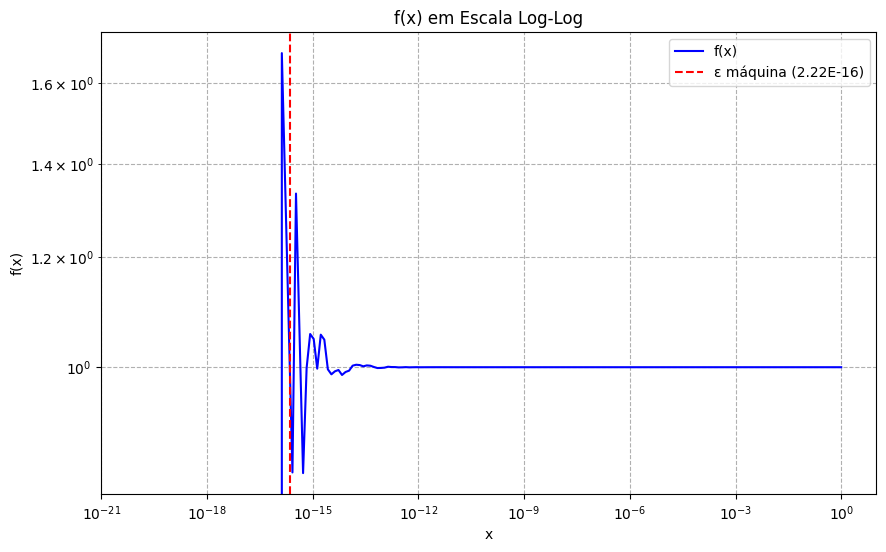

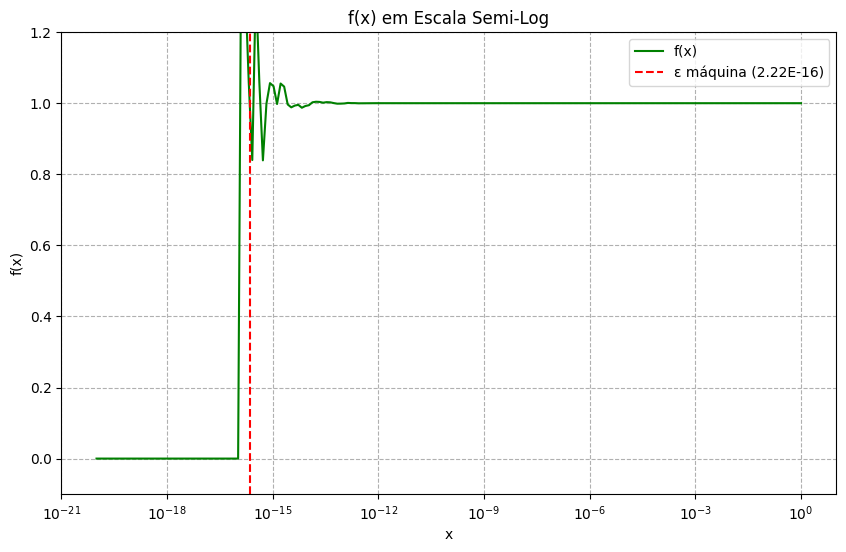

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Função principal
# =====================================================
def funcao_f(x: float) -> float:
    """Calcula f(x) = ((1+x) - 1)/x"""
    return ((1 + x) - 1) / x

def avaliar_pontos_especificos(pontos):
    """Mostra valores de f(x) em pontos escolhidos"""
    print("\nValores de f(x) em pontos específicos:\n")
    print(f"{'x':<12} | {'f(x)':<22}")
    print("-" * 37)
    for valor in pontos:
        resultado = funcao_f(valor)
        print(f"{valor:<12.1E} | {resultado:<22.16f}")

def gerar_graficos():
    """Gera os gráficos de f(x) em escala log-log e semi-log"""
    x_vals = np.logspace(-20, 0, 200)       # de 10^-20 até 1
    y_vals = funcao_f(x_vals)               # aplica f em vetor (numpy broadcasting)

    eps_maquina = np.finfo(float).eps
    print(f"\nÉpsilon de máquina (float64): {eps_maquina:.2E}")

    # --- Gráfico 1: log-log ---
    plt.figure(figsize=(10, 6))
    plt.loglog(x_vals, y_vals, 'b-', lw=1.5, label="f(x)")
    plt.axvline(eps_maquina, color='r', linestyle='--', label=f"ε máquina ({eps_maquina:.2E})")
    plt.title("f(x) em Escala Log-Log")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.savefig("fx_loglog.png")
    print("Gráfico 'fx_loglog.png' salvo.")

    # --- Gráfico 2: semilogx ---
    plt.figure(figsize=(10, 6))
    plt.semilogx(x_vals, y_vals, 'g-', lw=1.5, label="f(x)")
    plt.axvline(eps_maquina, color='r', linestyle='--', label=f"ε máquina ({eps_maquina:.2E})")
    plt.title("f(x) em Escala Semi-Log")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.ylim(-0.1, 1.2)
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.savefig("fx_semilog.png")
    print("Gráfico 'fx_semilog.png' salvo.")

    plt.show()

# =====================================================
# Execução
# =====================================================
if __name__ == "__main__":
    print("="*55)
    print("Caso de Estudo II: Identidade Numérica")
    print("="*55)

    pontos_teste = [1e-12, 1e-13, 1e-14, 1e-15, 1e-16, 1e-17]
    avaliar_pontos_especificos(pontos_teste)
    gerar_graficos()
